<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/bond_zscore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Z-Score + RSI 複合戦略 (GJGC10 - GJGC2) ===
総利益 (Total PnL): 0.7950
純利益 (Net PnL): 0.6200
取引回数: 35 回


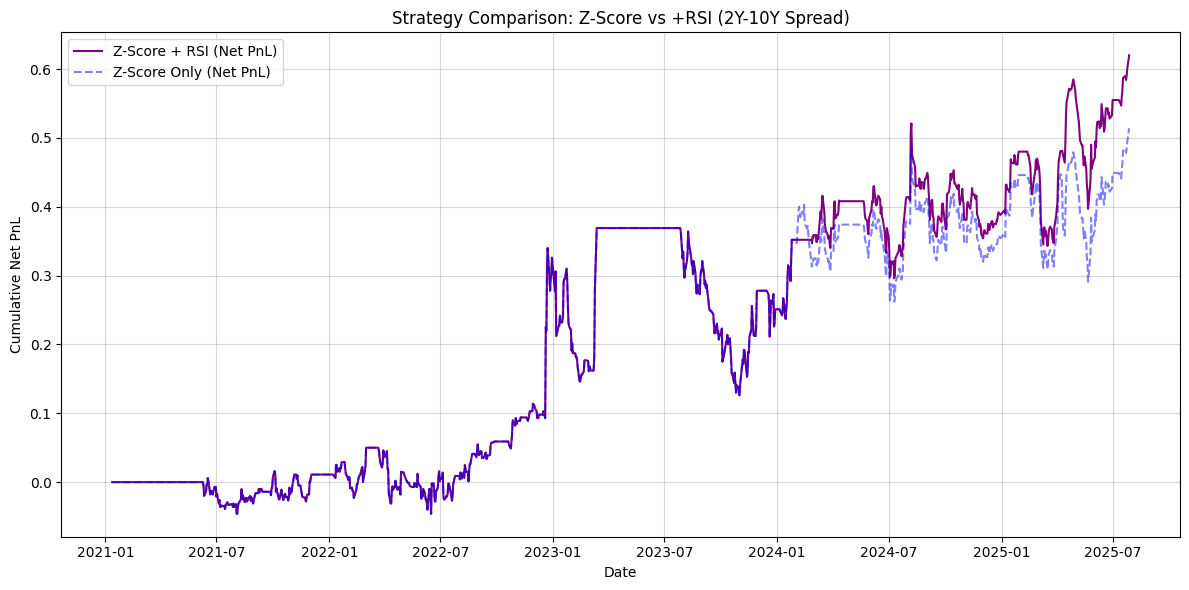

In [19]:
# 2年債(GJGC2)と10年債(GJGC10)でZスコア+RSI戦略をテスト
# 2Y-10Yで最適だったパラメータ(z_window=90, entry_z=1.5)を使用
df_res_rsi_2_10, total_pnl_2_10, net_pnl_2_10, trades_2_10 = backtest_zscore_rsi(
    df_bond, 'GJGC10', 'GJGC2',
    z_window=90, rsi_window=14, entry_z=1.5, rsi_lower=40, rsi_upper=60
)

print(f"=== Z-Score + RSI 複合戦略 (GJGC10 - GJGC2) ===")
print(f"総利益 (Total PnL): {total_pnl_2_10:.4f}")
print(f"純利益 (Net PnL): {net_pnl_2_10:.4f}")
print(f"取引回数: {trades_2_10} 回")

# 累積純利益のプロット
plt.figure(figsize=(12, 6))
plt.plot(df_res_rsi_2_10.index, df_res_rsi_2_10['Cumulative_Net_PnL'], label='Z-Score + RSI (Net PnL)', color='purple')

# Zスコア単体（Window=90, Z=1.5）の結果と比較できればプロット
if 'df_pnl_2_10' in globals():
    plt.plot(df_pnl_2_10.index, df_pnl_2_10['Cumulative_Net_PnL'], label='Z-Score Only (Net PnL)', color='blue', alpha=0.5, linestyle='--')

plt.title('Strategy Comparison: Z-Score vs +RSI (2Y-10Y Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

=== Z-Score + MACD 複合戦略 (GJGC30 - GJGC5) ===
総利益 (Total PnL): 0.0399
純利益 (Net PnL): -0.0401
取引回数: 16 回


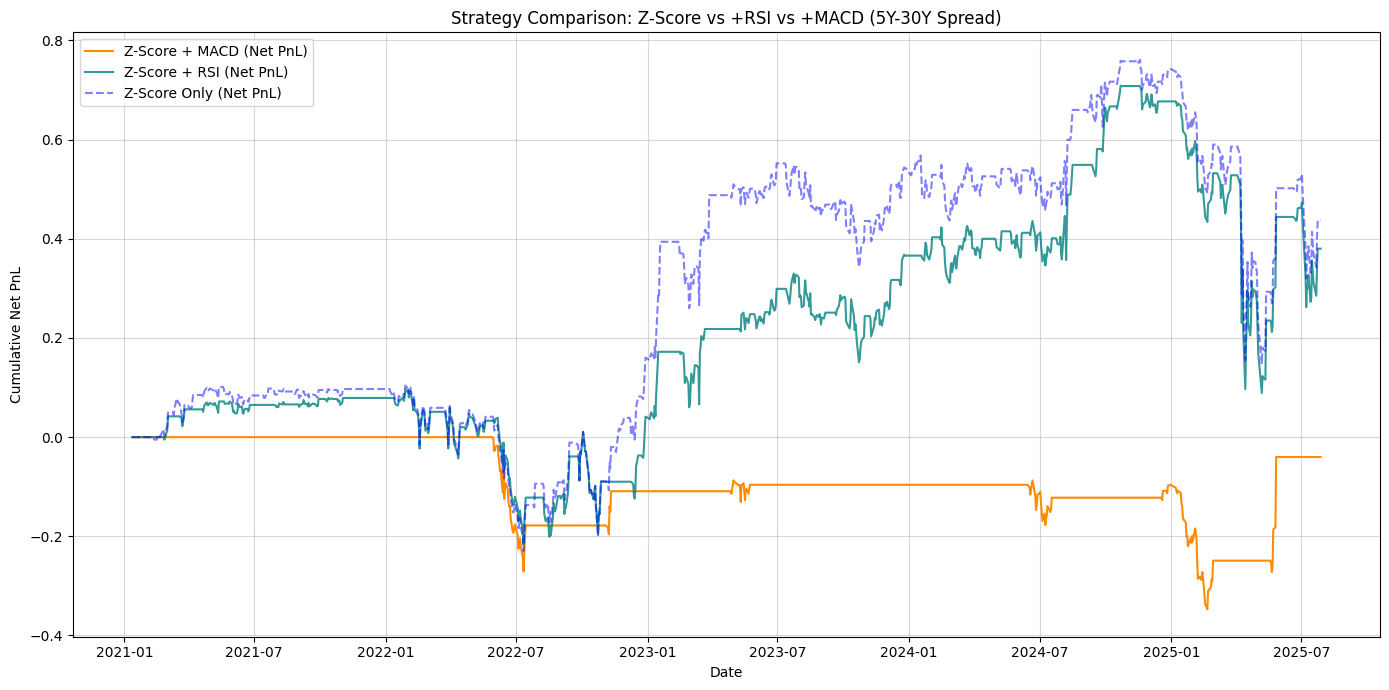

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_zscore_macd(df_input, leg1, leg2, z_window=20, entry_z=1.5, exit_z=0.0, macd_fast=12, macd_slow=26, macd_signal=9, transaction_cost=0.005):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    # スプレッドとZスコアの計算
    df['Spread'] = df[leg1] - df[leg2]
    df['Rolling_Mean'] = df['Spread'].rolling(window=z_window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=z_window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    # MACDの計算
    df['EMA_fast'] = df['Spread'].ewm(span=macd_fast, adjust=False).mean()
    df['EMA_slow'] = df['Spread'].ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['Signal_Line'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()

    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values
    macds = df['MACD'].values
    signals = df['Signal_Line'].values

    for i in range(len(df)):
        z = z_scores[i]
        macd = macds[i]
        signal = signals[i]

        if np.isnan(z) or np.isnan(macd) or np.isnan(signal):
            continue

        # エントリーとエグジットのロジック
        if position == 0:
            # Zスコアが割高 かつ MACDがデッドクロス/下落傾向
            if z > entry_z and macd < signal:
                position = -1
            # Zスコアが割安 かつ MACDがゴールデンクロス/上昇傾向
            elif z < -entry_z and macd > signal:
                position = 1
        elif position == -1:
            if z <= exit_z:
                position = 0
        elif position == 1:
            if z >= exit_z:
                position = 0

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    # 取引コストと純利益の計算
    position_changes = (df['Position'].diff().abs() > 0)
    df['Cost'] = position_changes * transaction_cost
    df['Net_Daily_PnL'] = df['Strategy_PnL'].fillna(0) - df['Cost'].fillna(0)
    df['Cumulative_Net_PnL'] = df['Net_Daily_PnL'].cumsum()

    total_pnl = df['Strategy_PnL'].sum()
    num_transactions = int(position_changes.sum())
    net_pnl = total_pnl - (num_transactions * transaction_cost)

    return df, total_pnl, net_pnl, num_transactions

# 5年債(GJGC5)と30年債(GJGC30)でZスコア+MACD戦略をテスト
df_res_macd, total_pnl_macd, net_pnl_macd, trades_macd = backtest_zscore_macd(
    df_bond, 'GJGC30', 'GJGC5',
    z_window=20, entry_z=1.5
)

print(f"=== Z-Score + MACD 複合戦略 (GJGC30 - GJGC5) ===")
print(f"総利益 (Total PnL): {total_pnl_macd:.4f}")
print(f"純利益 (Net PnL): {net_pnl_macd:.4f}")
print(f"取引回数: {trades_macd} 回")

# 累積純利益のプロット (既存の戦略と比較)
plt.figure(figsize=(14, 7))
plt.plot(df_res_macd.index, df_res_macd['Cumulative_Net_PnL'], label='Z-Score + MACD (Net PnL)', color='darkorange')

if 'df_res_rsi' in globals():
    plt.plot(df_res_rsi.index, df_res_rsi['Cumulative_Net_PnL'], label='Z-Score + RSI (Net PnL)', color='teal', alpha=0.8)

if 'df_pnl_5_30' in globals():
    plt.plot(df_pnl_5_30.index, df_pnl_5_30['Cumulative_Net_PnL'], label='Z-Score Only (Net PnL)', color='blue', alpha=0.5, linestyle='--')

plt.title('Strategy Comparison: Z-Score vs +RSI vs +MACD (5Y-30Y Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

=== Z-Score + RSI 複合戦略 (GJGC30 - GJGC5) ===
総利益 (Total PnL): 0.8801
純利益 (Net PnL): 0.3801
取引回数: 100 回


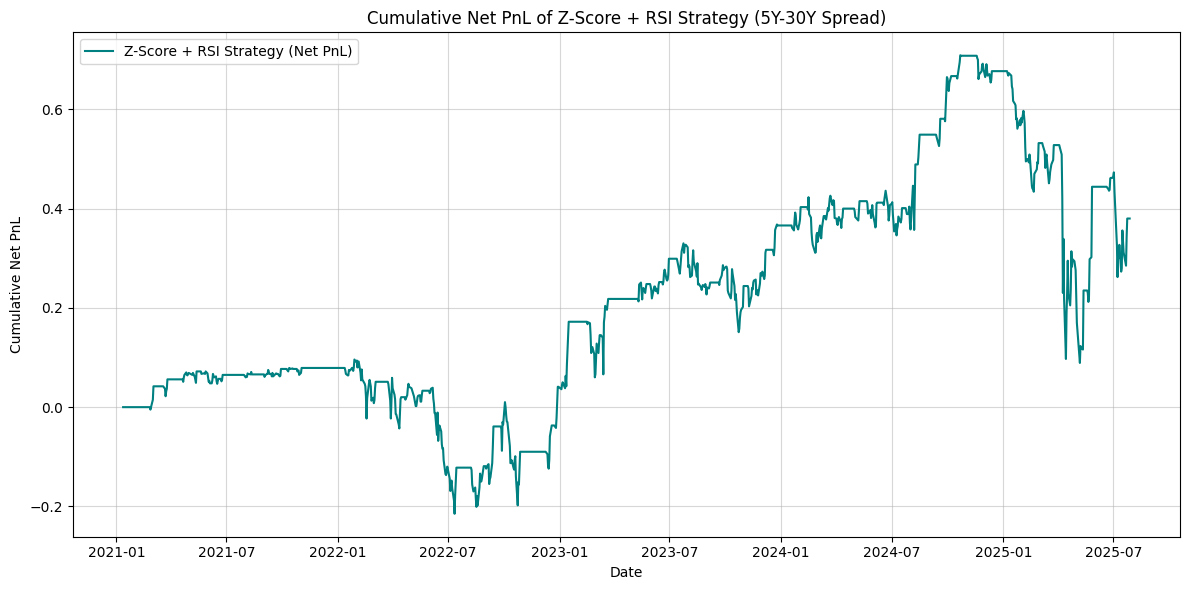

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_zscore_rsi(df_input, leg1, leg2, z_window=20, rsi_window=14, entry_z=1.5, rsi_lower=40, rsi_upper=60, exit_z=0.0, transaction_cost=0.005):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    # スプレッドとZスコアの計算
    df['Spread'] = df[leg1] - df[leg2]
    df['Rolling_Mean'] = df['Spread'].rolling(window=z_window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=z_window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    # スプレッドに対するRSIの計算
    delta = df['Spread'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values
    rsis = df['RSI'].values

    for i in range(len(df)):
        z = z_scores[i]
        rsi = rsis[i]

        if np.isnan(z) or np.isnan(rsi):
            continue

        # エントリーとエグジットのロジック
        if position == 0:
            if z > entry_z and rsi > rsi_upper:
                position = -1  # ショート
            elif z < -entry_z and rsi < rsi_lower:
                position = 1   # ロング
        elif position == -1:
            if z <= exit_z:
                position = 0   # 利益確定
        elif position == 1:
            if z >= exit_z:
                position = 0   # 利益確定

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    # 取引コストと純利益の計算
    position_changes = (df['Position'].diff().abs() > 0)
    df['Cost'] = position_changes * transaction_cost
    df['Net_Daily_PnL'] = df['Strategy_PnL'].fillna(0) - df['Cost'].fillna(0)
    df['Cumulative_Net_PnL'] = df['Net_Daily_PnL'].cumsum()

    total_pnl = df['Strategy_PnL'].sum()
    num_transactions = int(position_changes.sum())
    net_pnl = total_pnl - (num_transactions * transaction_cost)

    return df, total_pnl, net_pnl, num_transactions

# 5年債(GJGC5)と30年債(GJGC30)でZスコア+RSI戦略をテスト
df_res_rsi, total_pnl, net_pnl, trades = backtest_zscore_rsi(
    df_bond, 'GJGC30', 'GJGC5',
    z_window=20, rsi_window=14, entry_z=1.5, rsi_lower=40, rsi_upper=60
)

print(f"=== Z-Score + RSI 複合戦略 (GJGC30 - GJGC5) ===")
print(f"総利益 (Total PnL): {total_pnl:.4f}")
print(f"純利益 (Net PnL): {net_pnl:.4f}")
print(f"取引回数: {trades} 回")

# 累積純利益のプロット
plt.figure(figsize=(12, 6))
plt.plot(df_res_rsi.index, df_res_rsi['Cumulative_Net_PnL'], label='Z-Score + RSI Strategy (Net PnL)', color='teal')
plt.title('Cumulative Net PnL of Z-Score + RSI Strategy (5Y-30Y Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
results_20y_7y = []

# テストするパラメータの候補（念のため再定義）
windows = [10, 20, 30, 40, 60, 90]
entry_zs = [1.0, 1.5, 2.0, 2.5, 3.0]
transaction_cost = 0.005

# グリッドサーチの実行 (GJGC20 - GJGC7)
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_spread(df_bond, 'GJGC20', 'GJGC7', w, z, transaction_cost=transaction_cost)
        results_20y_7y.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_20y_7y = pd.DataFrame(results_20y_7y)
df_results_20y_7y_sorted = df_results_20y_7y.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 7年債(GJGC7)と20年債(GJGC20)のスプレッド バックテスト結果 (上位10件) ===")
display(df_results_20y_7y_sorted.head(10))

=== 7年債(GJGC7)と20年債(GJGC20)のスプレッド バックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,90,3.0,0.398,0.318,16
1,40,1.5,0.668,0.308,72
2,20,1.5,0.906,0.286,124
3,20,1.0,1.128,0.283,169
4,20,2.0,0.680,0.280,80
5,20,2.5,0.449,0.239,42
6,40,3.0,0.300,0.230,14
7,30,1.0,0.864,0.229,127
8,40,1.0,0.693,0.213,96
9,30,2.5,0.396,0.196,40


In [15]:
import numpy as np

# 提供された翌日のデータ
gjgc5_new = 1.108
gjgc30_new = 2.995
new_spread = gjgc30_new - gjgc5_new

# GJGC30-GJGC5の最適パラメータである Window = 20 を使用
window = 20

# 既存のデータセットから最新の Window-1 日分 (19日分) のスプレッドを取得
past_spreads = (df_bond['GJGC30'] - df_bond['GJGC5']).tail(window - 1).tolist()

# 新しいスプレッドを追加して20日分の配列にする
rolling_spreads = past_spreads + [new_spread]

# 平均と標準偏差を計算（不偏標準偏差 ddof=1 を使用）
rolling_mean = np.mean(rolling_spreads)
rolling_std = np.std(rolling_spreads, ddof=1)

# Zスコアを計算
new_z_score = (new_spread - rolling_mean) / rolling_std

print(f"=== 翌日の GJGC30 - GJGC5 (5Y-30Y) データ ===")
print(f"新しいスプレッド: {new_spread:.4f}")
print(f"{window}日間の移動平均: {rolling_mean:.4f}")
print(f"{window}日間の標準偏差: {rolling_std:.4f}")
print(f"Zスコア (Window={window}): {new_z_score:.4f}")

=== 翌日の GJGC30 - GJGC5 (5Y-30Y) データ ===
新しいスプレッド: 1.8870
20日間の移動平均: 1.9309
20日間の標準偏差: 0.0661
Zスコア (Window=20): -0.6637


=== 2年債(GJGC2)と5年債(GJGC5)のスプレッド バックテスト結果 (上位5件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,90,2.5,0.345,0.265,16
1,90,3.0,0.259,0.219,8
2,90,2.0,0.313,0.203,22
3,40,1.5,0.470,0.125,69
4,30,2.5,0.293,0.123,34


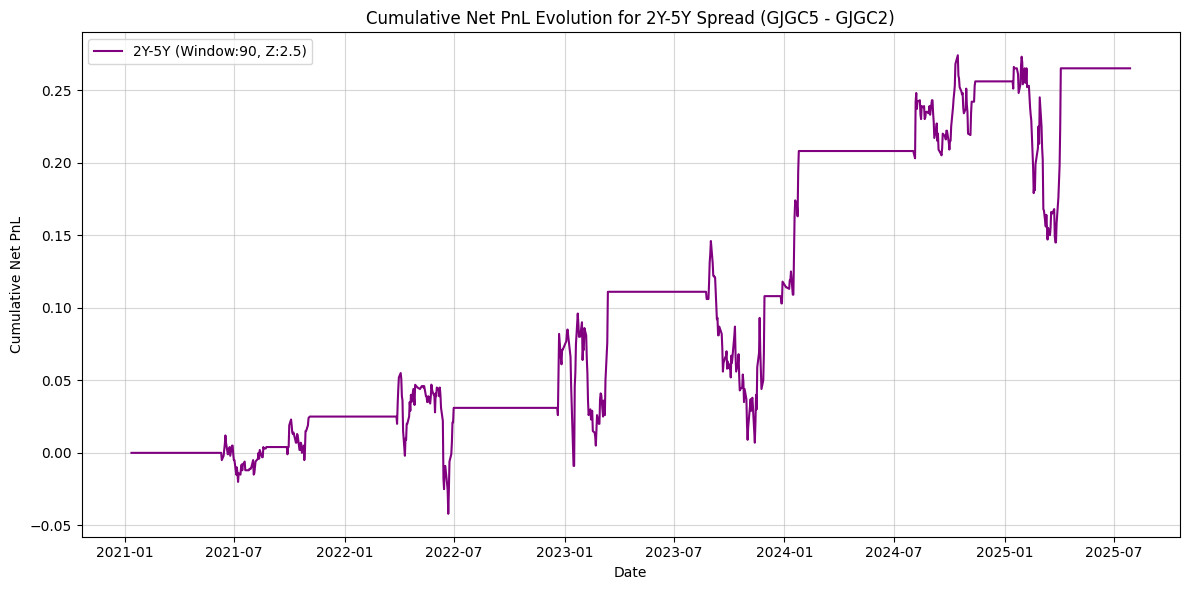

In [14]:
results_5y_2y = []

# グリッドサーチの実行 (GJGC5 - GJGC2)
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_spread(df_bond, 'GJGC5', 'GJGC2', w, z, transaction_cost=transaction_cost)
        results_5y_2y.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_5y_2y = pd.DataFrame(results_5y_2y)
df_results_5y_2y_sorted = df_results_5y_2y.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print("=== 2年債(GJGC2)と5年債(GJGC5)のスプレッド バックテスト結果 (上位5件) ===")
display(df_results_5y_2y_sorted.head(5))

# 最適パラメータの取得
best_w_5_2 = int(df_results_5y_2y_sorted.iloc[0]['Window'])
best_z_5_2 = df_results_5y_2y_sorted.iloc[0]['Entry_Z']

# 累積純利益の推移を取得
df_pnl_5_2 = get_cumulative_pnl_series(df_bond, 'GJGC5', 'GJGC2', best_w_5_2, best_z_5_2)

# グラフの描画
plt.figure(figsize=(12, 6))
plt.plot(df_pnl_5_2.index, df_pnl_5_2['Cumulative_Net_PnL'], label=f'2Y-5Y (Window:{best_w_5_2}, Z:{best_z_5_2})', color='purple')
plt.title('Cumulative Net PnL Evolution for 2Y-5Y Spread (GJGC5 - GJGC2)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net PnL')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


In [13]:
import numpy as np

# 提供された翌日のデータ
new_data = {
    'GJGC2': 0.841,
    'GJGC5': 1.108,
    'GJGC7': 1.277,
    'GJGC10': 1.565,
    'GJGC15': 2.136,
    'GJGC20': 2.518,
    'GJGC30': 2.995,
    'GJGC40': 3.288
}

# スプレッドの計算 (GJGC30 - GJGC5)
new_spread = new_data['GJGC30'] - new_data['GJGC5']

# GJGC30-GJGC5の最適パラメータである Window = 20 を使用
window = 20

# 既存のデータセットから最新の Window-1 日分 (19日分) のスプレッドを取得
spread_series = df_bond['GJGC30'] - df_bond['GJGC5']
past_spreads = spread_series.tail(window - 1).tolist()

# 新しいスプレッドを追加して20日分の配列にする
rolling_spreads = past_spreads + [new_spread]

# 平均と標準偏差を計算（Pandasのrolling.std()と同じ不偏標準偏差 ddof=1 を使用）
rolling_mean = np.mean(rolling_spreads)
rolling_std = np.std(rolling_spreads, ddof=1)

# Zスコアを計算
new_z_score = (new_spread - rolling_mean) / rolling_std

print(f"=== 翌日の GJGC30 - GJGC5 (5Y-30Y) データ ===")
print(f"新しいスプレッド: {new_spread:.4f}")
print(f"{window}日間の移動平均: {rolling_mean:.4f}")
print(f"{window}日間の標準偏差: {rolling_std:.4f}")
print(f"Zスコア (Window={window}): {new_z_score:.4f}")


=== 翌日の GJGC30 - GJGC5 (5Y-30Y) データ ===
新しいスプレッド: 1.8870
20日間の移動平均: 1.9309
20日間の標準偏差: 0.0661
Zスコア (Window=20): -0.6637


In [11]:
results_10y_7y = []

# グリッドサーチの実行 (GJGC10 - GJGC7)
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_spread(df_bond, 'GJGC10', 'GJGC7', w, z, transaction_cost=transaction_cost)
        results_10y_7y.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_10y_7y = pd.DataFrame(results_10y_7y)
df_results_10y_7y_sorted = df_results_10y_7y.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 7年債(GJGC7)と10年債(GJGC10)のスプレッド バックテスト結果 (上位10件) ===")
display(df_results_10y_7y_sorted.head(10))


=== 7年債(GJGC7)と10年債(GJGC10)のスプレッド バックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,60,2.5,0.668,0.498,34
1,40,2.5,0.612,0.437,35
2,90,1.0,0.780,0.415,73
3,90,1.5,0.666,0.406,52
4,40,2.0,0.701,0.396,61
5,30,2.5,0.565,0.380,37
6,90,3.0,0.469,0.379,18
7,60,1.5,0.706,0.361,69
8,90,2.5,0.458,0.348,22
9,40,1.5,0.788,0.343,89


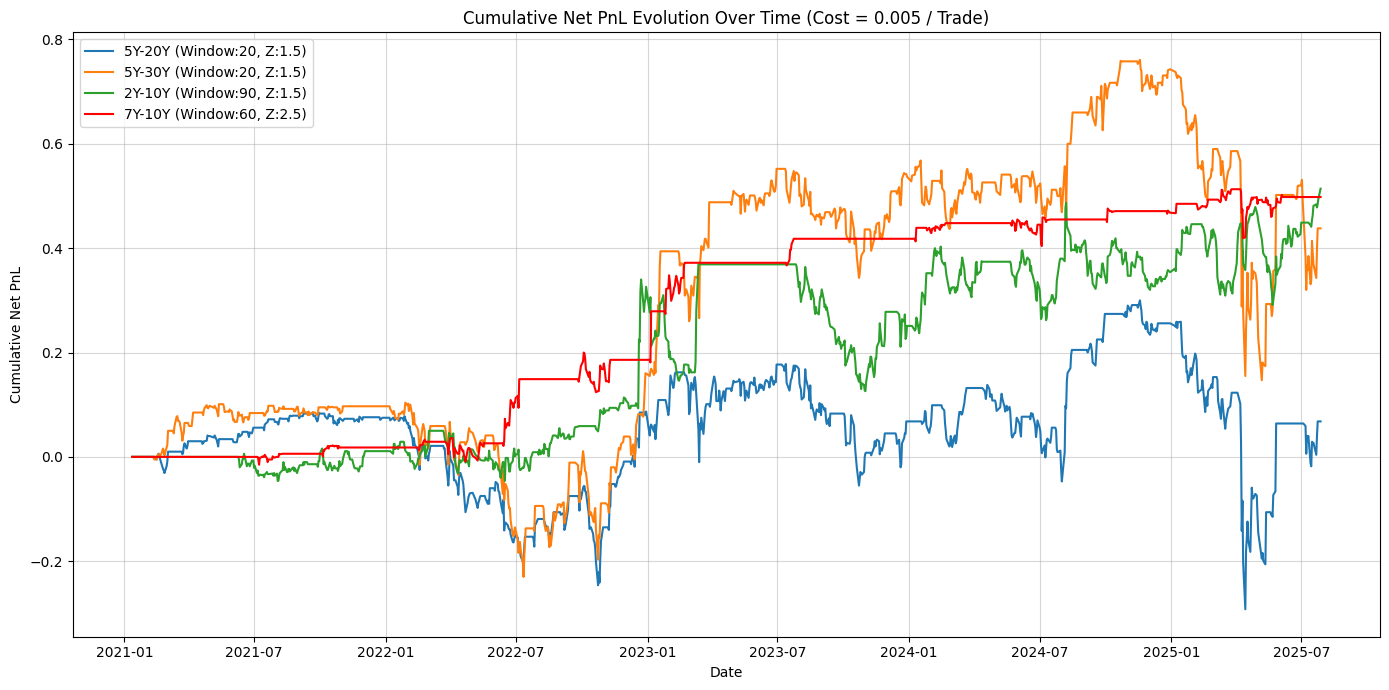

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 時系列での累積純利益を取得する関数
def get_cumulative_pnl_series(df_input, leg1, leg2, window, entry_z, exit_z=0.0, transaction_cost=0.005):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    df['Spread'] = df[leg1] - df[leg2]
    df['Rolling_Mean'] = df['Spread'].rolling(window=window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values

    for i in range(len(df)):
        z = z_scores[i]
        if np.isnan(z):
            continue

        if position == 0:
            if z > entry_z:
                position = -1
            elif z < -entry_z:
                position = 1
        elif position == -1:
            if z <= exit_z:
                position = 0
        elif position == 1:
            if z >= exit_z:
                position = 0

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    # 日次の取引コストを計算
    df['Position_Change'] = df['Position'].diff().abs() > 0
    df['Cost'] = df['Position_Change'] * transaction_cost

    # 日次の純利益 = 戦略の利益 - 取引コスト
    df['Net_Daily_PnL'] = df['Strategy_PnL'].fillna(0) - df['Cost'].fillna(0)

    # 累積純利益
    df['Cumulative_Net_PnL'] = df['Net_Daily_PnL'].cumsum()

    return df[['Cumulative_Net_PnL']]

# 各ペアのトップ設定の推移を取得
# 5Y-20Y: Window 20, Z 1.5
df_pnl_5_20 = get_cumulative_pnl_series(df_bond, 'GJGC20', 'GJGC5', 20, 1.5)
# 5Y-30Y: Window 20, Z 1.5
df_pnl_5_30 = get_cumulative_pnl_series(df_bond, 'GJGC30', 'GJGC5', 20, 1.5)
# 2Y-10Y: Window 90, Z 1.5
df_pnl_2_10 = get_cumulative_pnl_series(df_bond, 'GJGC10', 'GJGC2', 90, 1.5)
# 7Y-10Y: Window 60, Z 2.5
df_pnl_7_10 = get_cumulative_pnl_series(df_bond, 'GJGC10', 'GJGC7', 60, 2.5)

# グラフの描画
plt.figure(figsize=(14, 7))
plt.plot(df_pnl_5_20.index, df_pnl_5_20['Cumulative_Net_PnL'], label='5Y-20Y (Window:20, Z:1.5)')
plt.plot(df_pnl_5_30.index, df_pnl_5_30['Cumulative_Net_PnL'], label='5Y-30Y (Window:20, Z:1.5)')
plt.plot(df_pnl_2_10.index, df_pnl_2_10['Cumulative_Net_PnL'], label='2Y-10Y (Window:90, Z:1.5)')
plt.plot(df_pnl_7_10.index, df_pnl_7_10['Cumulative_Net_PnL'], label='7Y-10Y (Window:60, Z:2.5)', color='red')

plt.title('Cumulative Net PnL Evolution Over Time (Cost = 0.005 / Trade)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net PnL')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


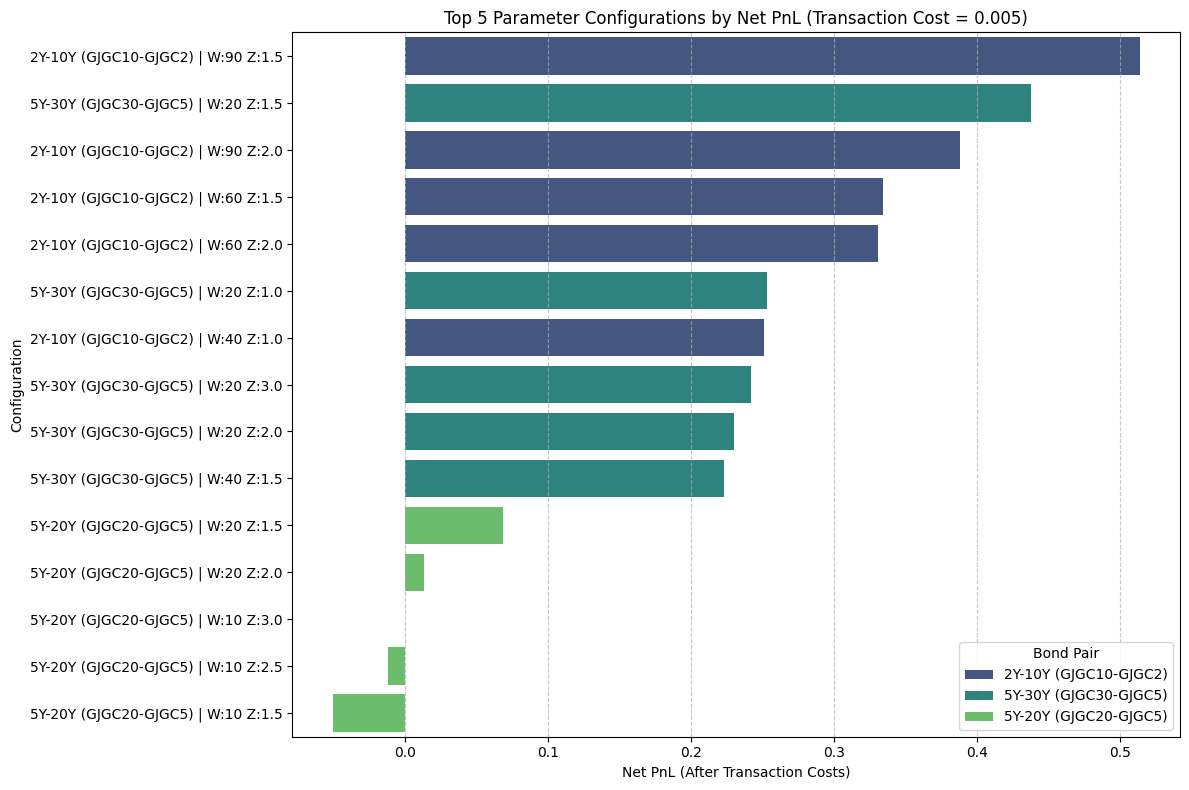

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 各ペアの上位5件を抽出してペア名を追加
df_5_20 = df_results_cost_sorted.head(5).copy()
df_5_20['Pair'] = '5Y-20Y (GJGC20-GJGC5)'

df_5_30 = df_results_30y_sorted.head(5).copy()
df_5_30['Pair'] = '5Y-30Y (GJGC30-GJGC5)'

df_2_10 = df_results_10y_2y_sorted.head(5).copy()
df_2_10['Pair'] = '2Y-10Y (GJGC10-GJGC2)'

# データを結合
df_compare = pd.concat([df_5_20, df_5_30, df_2_10])

# グラフ用にラベルを作成 (ペア名 + Window + Entry_Z)
df_compare['Label'] = df_compare['Pair'] + ' | W:' + df_compare['Window'].astype(str) + ' Z:' + df_compare['Entry_Z'].astype(str)

# 純利益の昇順で並び替え（グラフの下から上へ大きい順にするため）
df_compare = df_compare.sort_values(by='Net_PnL', ascending=False)

# グラフの描画
plt.figure(figsize=(12, 8))
sns.barplot(x='Net_PnL', y='Label', hue='Pair', data=df_compare, dodge=False, palette='viridis')
plt.title('Top 5 Parameter Configurations by Net PnL (Transaction Cost = 0.005)')
plt.xlabel('Net PnL (After Transaction Costs)')
plt.ylabel('Configuration')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Bond Pair', loc='lower right')
plt.tight_layout()
plt.show()


In [8]:
results_10y_2y = []

# グリッドサーチの実行 (GJGC10 - GJGC2)
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_spread(df_bond, 'GJGC10', 'GJGC2', w, z, transaction_cost=transaction_cost)
        results_10y_2y.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_10y_2y = pd.DataFrame(results_10y_2y)
df_results_10y_2y_sorted = df_results_10y_2y.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 2年債(GJGC2)と10年債(GJGC10)のスプレッド バックテスト結果 (上位10件) ===")
display(df_results_10y_2y_sorted.head(10))


=== 2年債(GJGC2)と10年債(GJGC10)のスプレッド バックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,90,1.5,0.6890,0.5140,35
1,90,2.0,0.5280,0.3880,28
2,60,1.5,0.5440,0.3340,42
3,60,2.0,0.4911,0.3311,32
4,40,1.0,0.6460,0.2510,79
5,60,1.0,0.4800,0.2100,54
6,90,2.5,0.2419,0.1819,12
7,90,1.0,0.3450,0.1600,37
8,60,2.5,0.2400,0.1400,20
9,40,1.5,0.3940,0.1290,53


In [7]:
import pandas as pd
import numpy as np

# 任意の債券スプレッドでバックテストできる関数
def backtest_spread(df_input, leg1, leg2, window, entry_z, exit_z=0.0, transaction_cost=0.005):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    # 引数で指定された2つの債券のスプレッドを計算
    df['Spread'] = df[leg1] - df[leg2]
    df['Rolling_Mean'] = df['Spread'].rolling(window=window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values

    for i in range(len(df)):
        z = z_scores[i]
        if np.isnan(z):
            continue

        if position == 0:
            if z > entry_z:
                position = -1
            elif z < -entry_z:
                position = 1
        elif position == -1:
            if z <= exit_z:
                position = 0
        elif position == 1:
            if z >= exit_z:
                position = 0

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    # ポジションが変化した回数（取引回数）
    position_changes = (df['Position'].diff().abs() > 0).sum()

    # 総利益と純利益の計算
    total_pnl = df['Strategy_PnL'].sum()
    net_pnl = total_pnl - (position_changes * transaction_cost)

    return total_pnl, net_pnl, int(position_changes)

# テストするパラメータの候補
windows = [10, 20, 30, 40, 60, 90]
entry_zs = [1.0, 1.5, 2.0, 2.5, 3.0]
transaction_cost = 0.005

results_30y = []

# グリッドサーチの実行 (GJGC30 - GJGC5)
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_spread(df_bond, 'GJGC30', 'GJGC5', w, z, transaction_cost=transaction_cost)
        results_30y.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_30y = pd.DataFrame(results_30y)
df_results_30y_sorted = df_results_30y.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 5年債(GJGC5)と30年債(GJGC30)のスプレッド バックテスト結果 (上位10件) ===")
display(df_results_30y_sorted.head(10))


=== 5年債(GJGC5)と30年債(GJGC30)のスプレッド バックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,20,1.5,1.0480,0.4380,122
1,20,1.0,1.0930,0.2530,168
2,20,3.0,0.2820,0.2420,8
3,20,2.0,0.6301,0.2301,80
4,40,1.5,0.5630,0.2230,68
5,30,1.5,0.6341,0.2041,86
6,30,1.0,0.8030,0.1730,126
7,30,2.0,0.4381,0.1381,60
8,20,2.5,0.2211,0.0411,36
9,30,3.0,0.0911,0.0311,12


In [6]:
import pandas as pd
import numpy as np

# バックテスト関数（ポジション変更回数も返すように修正）
def backtest_with_transaction_costs(df_input, window, entry_z, exit_z=0.0, transaction_cost=0.005):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    df['Spread'] = df['GJGC20'] - df['GJGC5']
    df['Rolling_Mean'] = df['Spread'].rolling(window=window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values

    for i in range(len(df)):
        z = z_scores[i]
        if np.isnan(z):
            continue

        if position == 0:
            if z > entry_z:
                position = -1
            elif z < -entry_z:
                position = 1
        elif position == -1:
            if z <= exit_z:
                position = 0
        elif position == 1:
            if z >= exit_z:
                position = 0

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    # ポジションが変化した回数（取引回数）
    position_changes = (df['Position'].diff().abs() > 0).sum()

    # 総利益と純利益の計算
    total_pnl = df['Strategy_PnL'].sum()
    net_pnl = total_pnl - (position_changes * transaction_cost)

    return total_pnl, net_pnl, int(position_changes)

# テストするパラメータの候補
windows = [10, 20, 30, 40, 60, 90]
entry_zs = [1.0, 1.5, 2.0, 2.5, 3.0]
transaction_cost = 0.005

results_cost = []

# グリッドサーチの実行
for w in windows:
    for z in entry_zs:
        total_pnl, net_pnl, transactions = backtest_with_transaction_costs(df_bond, w, z, transaction_cost=transaction_cost)
        results_cost.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': total_pnl,
            'Net_PnL': net_pnl,
            'Transactions (Changes)': transactions
        })

# 結果をDataFrameにまとめて純利益が高い順にソート
df_results_cost = pd.DataFrame(results_cost)
df_results_cost_sorted = df_results_cost.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 取引コスト {transaction_cost} / 回 (ポジション変更毎) 考慮後のバックテスト結果 (上位10件) ===")
display(df_results_cost_sorted.head(10))


=== 取引コスト 0.005 / 回 (ポジション変更毎) 考慮後のバックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Net_PnL,Transactions (Changes)
0,20,1.5,0.6580,0.0680,118
1,20,2.0,0.3830,0.0130,74
2,10,3.0,0.0000,0.0000,0
3,10,2.5,0.0080,-0.0120,4
4,10,1.5,0.9240,-0.0510,195
5,30,3.0,-0.0320,-0.0920,12
6,10,2.0,0.2619,-0.1231,77
7,60,2.0,0.0580,-0.1320,38
8,60,1.0,0.1460,-0.1540,60
9,60,1.5,0.0540,-0.1660,44


In [5]:
# 取引コストを0.01とした場合の純利益（Net_PnL）を計算
cost_per_trade = 0.01

# 既存の結果データフレームのコピーを作成し、純利益の列を追加
df_results_with_cost = df_results.copy()
df_results_with_cost['Net_PnL'] = df_results_with_cost['Total_PnL'] - (df_results_with_cost['Trades'] * cost_per_trade)

# 純利益が高い順にソート
df_results_net_sorted = df_results_with_cost.sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"=== 取引コスト {cost_per_trade} 考慮後のバックテスト結果 (上位10件) ===")
display(df_results_net_sorted.head(10))

=== 取引コスト 0.01 考慮後のバックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Trades,Net_PnL
0,20,1.5,0.6580,59,0.0680
1,20,2.0,0.3830,37,0.0130
2,10,3.0,0.0000,0,0.0000
3,10,2.5,0.0080,2,-0.0120
4,10,1.5,0.9240,97,-0.0460
5,30,3.0,-0.0320,6,-0.0920
6,10,2.0,0.2619,38,-0.1181
7,60,2.0,0.0580,19,-0.1320
8,60,1.0,0.1460,30,-0.1540
9,60,1.5,0.0540,22,-0.1660


In [4]:
# 取引回数が40回以下のパラメータ設定を抽出し、収益が高い順に表示
low_trade_results = df_results_sorted[df_results_sorted['Trades'] <= 40]

print("=== 取引回数40回以下で収益が高い設定 ===")
display(low_trade_results.head(5))

=== 取引回数40回以下で収益が高い設定 ===


,Window,Entry_Z,Total_PnL,Trades
4,20,2.0,0.3830,37
5,10,2.0,0.2619,38
7,60,1.0,0.1460,30
8,30,1.5,0.1180,40
9,60,2.0,0.0580,19


In [3]:
import pandas as pd
import numpy as np

# バックテストを関数化
def backtest_pairs_trade(df_input, window, entry_z, exit_z=0.0):
    df = df_input.copy()
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Date', inplace=True)

    df['Spread'] = df['GJGC20'] - df['GJGC5']
    df['Rolling_Mean'] = df['Spread'].rolling(window=window).mean()
    df['Rolling_Std'] = df['Spread'].rolling(window=window).std()
    df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

    # シグナルとポジションの生成（配列化して高速化）
    positions = np.zeros(len(df))
    position = 0
    z_scores = df['Z_Score'].values

    for i in range(len(df)):
        z = z_scores[i]
        if np.isnan(z):
            continue

        if position == 0:
            if z > entry_z:
                position = -1
            elif z < -entry_z:
                position = 1
        elif position == -1:
            if z <= exit_z:
                position = 0
        elif position == 1:
            if z >= exit_z:
                position = 0

        positions[i] = position

    df['Position'] = positions
    df['Spread_Diff'] = df['Spread'].diff()
    df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

    total_pnl = df['Strategy_PnL'].sum()
    num_trades = int((df['Position'].diff().abs() > 0).sum() // 2)

    return total_pnl, num_trades

# テストするパラメータの候補
windows = [10, 20, 30, 40, 60, 90]
entry_zs = [1.0, 1.5, 2.0, 2.5, 3.0]

results = []

# グリッドサーチの実行
for w in windows:
    for z in entry_zs:
        pnl, trades = backtest_pairs_trade(df_bond, w, z)
        results.append({
            'Window': w,
            'Entry_Z': z,
            'Total_PnL': pnl,
            'Trades': trades
        })

# 結果をDataFrameにまとめて収益が高い順にソート
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='Total_PnL', ascending=False).reset_index(drop=True)

# 上位10個のパラメータ設定を表示
print("=== バックテスト結果 (上位10件) ===")
display(df_results_sorted.head(10))

=== バックテスト結果 (上位10件) ===


,Window,Entry_Z,Total_PnL,Trades
0,10,1.5,0.9240,97
1,10,1.0,0.8870,120
2,20,1.5,0.6580,59
3,20,1.0,0.4890,77
4,20,2.0,0.3830,37
5,10,2.0,0.2619,38
6,30,1.0,0.1859,59
7,60,1.0,0.1460,30
8,30,1.5,0.1180,40
9,60,2.0,0.0580,19


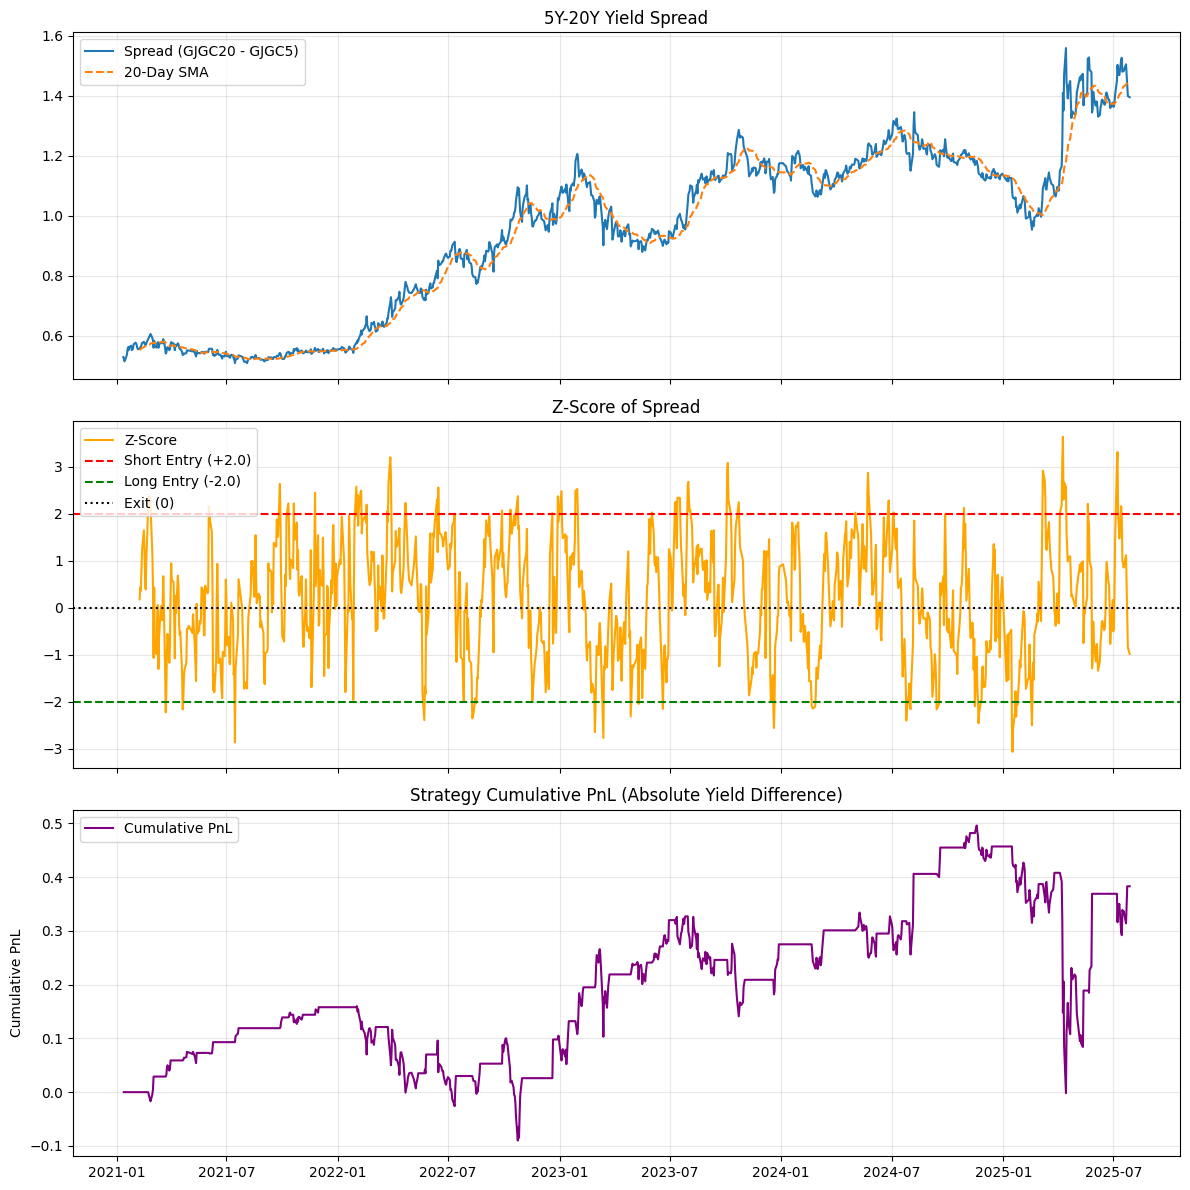

Total Cumulative PnL: 0.3830
Total Trades (Entry signals): 37


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データのコピーと前処理
df = df_bond.copy()
df['Date'] = pd.to_datetime(df['Unnamed: 0'])
df.set_index('Date', inplace=True)

# 1. スプレッドの計算 (20年債 - 5年債)
df['Spread'] = df['GJGC20'] - df['GJGC5']

# 戦略のパラメータ設定
window = 20       # 移動平均の期間
entry_z = 2.0     # エントリーのZスコア閾値
exit_z = 0.0      # エグジットのZスコア閾値

# 2. Zスコアの計算
df['Rolling_Mean'] = df['Spread'].rolling(window=window).mean()
df['Rolling_Std'] = df['Spread'].rolling(window=window).std()
df['Z_Score'] = (df['Spread'] - df['Rolling_Mean']) / df['Rolling_Std']

# 3. シグナルとポジションの生成
# +1: スプレッド拡大を期待 (Buy Spread), -1: スプレッド縮小を期待 (Sell Spread), 0: ノーポジ
df['Position'] = 0
position = 0

for i in range(len(df)):
    z = df['Z_Score'].iloc[i]

    if pd.isna(z):
        df.iloc[i, df.columns.get_loc('Position')] = 0
        continue

    if position == 0:
        if z > entry_z:
            position = -1  # スプレッドが広がりすぎ -> 縮小を見込んでショート
        elif z < -entry_z:
            position = 1   # スプレッドが縮小しすぎ -> 拡大を見込んでロング
    elif position == -1:
        if z <= exit_z:
            position = 0   # 平均に戻ったら利益確定
    elif position == 1:
        if z >= exit_z:
            position = 0   # 平均に戻ったら利益確定

    df.iloc[i, df.columns.get_loc('Position')] = position

# 4. リターンの計算 (スプレッドの差分で計算)
# 翌日のスプレッド変化分を獲得するため、前日のポジションを乗算
df['Spread_Diff'] = df['Spread'].diff()
df['Strategy_PnL'] = df['Position'].shift(1) * df['Spread_Diff']

# 累積損益の計算
df['Cumulative_PnL'] = df['Strategy_PnL'].cumsum()

# 5. 結果のプロット
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# スプレッドの推移
axes[0].plot(df.index, df['Spread'], label='Spread (GJGC20 - GJGC5)')
axes[0].plot(df.index, df['Rolling_Mean'], label=f'{window}-Day SMA', linestyle='--')
axes[0].set_title('5Y-20Y Yield Spread')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Zスコアの推移
axes[1].plot(df.index, df['Z_Score'], label='Z-Score', color='orange')
axes[1].axhline(entry_z, color='red', linestyle='--', label=f'Short Entry (+{entry_z})')
axes[1].axhline(-entry_z, color='green', linestyle='--', label=f'Long Entry (-{entry_z})')
axes[1].axhline(exit_z, color='black', linestyle=':', label='Exit (0)')
axes[1].set_title('Z-Score of Spread')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# 累積損益の推移
axes[2].plot(df.index, df['Cumulative_PnL'], label='Cumulative PnL', color='purple')
axes[2].set_title('Strategy Cumulative PnL (Absolute Yield Difference)')
axes[2].set_ylabel('Cumulative PnL')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# パフォーマンスのサマリー
total_pnl = df['Cumulative_PnL'].iloc[-1]
print(f"Total Cumulative PnL: {total_pnl:.4f}")
print(f"Total Trades (Entry signals): {(df['Position'].diff().abs() > 0).sum() // 2}")

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df_bond = pd.read_csv('/content/債券複利データセット3.csv')

# Display the first 5 rows of the DataFrame
display(df_bond.head())

,Unnamed: 0,GJGC2,GJGC5,GJGC7,GJGC10,GJGC15,GJGC20,GJGC30,GJGC40
0,2021/1/12,-0.128,-0.114,-0.080,0.030,0.242,0.414,0.649,0.666
1,2021/1/13,-0.128,-0.119,-0.084,0.025,0.231,0.405,0.635,0.649
2,2021/1/14,-0.123,-0.104,-0.079,0.030,0.231,0.410,0.643,0.661
3,2021/1/15,-0.129,-0.104,-0.079,0.030,0.226,0.414,0.649,0.670
4,2021/1/18,-0.129,-0.098,-0.069,0.045,0.252,0.438,0.658,0.679
